# Multi-Stage SP – Builder Debug Notebook
**Purpose:** isolate and fix all bugs arising from leaf/root node handling
in `build_multisp_model`.

## Bug inventory (identified before running)
| # | Location | Symptom | Root cause |
|---|----------|---------|------------|
| 1 | `temp_dynamics`, children of root | `KeyError` on `m.Heat[r,0]` / `m.Vent[0]` / `m.O1[0]` | When `pid==0`, the code sets `dec_node=nid` but still uses `pid` in the RHS for `Heat`, `Vent`, and `occ()` — all indexed on the root which is **not** in `N_int`. |
| 2 | `price_by_node` / `occ_by_node` dicts | Param initialisation silently missing nodes | Both dicts filter `internal_nodes` with `centroid is not None`, but then also need to guard against leaf nodes accidentally appearing. |
| 3 | `_path_to_root` | Objective may silently skip stage-1 costs | Walk stops when `tree[nid]['parent'] is None`, which is correct, but the starting node is `leaf['parent']`, so cost at stage H (leaves themselves) is never accumulated — this is intentional (leaves have no decisions) but must be verified. |

Each section below tests one concern in isolation before assembling the corrected builder.

## 1. Imports & system parameters

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyomo.environ import (
    ConcreteModel, Set, Param, Var, Objective, Constraint, Block,
    SolverFactory, NonNegativeReals, minimize, Binary, value
)
from pyomo.opt import TerminationCondition


In [2]:
def get_fixed_data():
    """
    Returns the fixed system characteristics.
    THIS FUNCTION SHOULD NOT BE CHANGED.
    """
    num_timeslots = 10
    return {
        'num_timeslots'              : num_timeslots,
        'initial_temperature'        : 21.0,
        'previous_initial_temperature': 21.0,
        'initial_humidity'           : 40.0,
        'heating_max_power'          : 3.0,       # Pr  (kW)
        'heat_exchange_coeff'        : 0.6,        # ζ_exch
        'heating_efficiency_coeff'   : 1.0,        # ζ_conv
        'thermal_loss_coeff'         : 0.1,        # ζ_loss
        'heat_vent_coeff'            : 0.7,        # ζ_cool
        'heat_occupancy_coeff'       : 0.02,       # ζ_occ
        'temp_min_comfort_threshold' : 18.0,       # T_low
        'temp_OK_threshold'          : 22.0,       # T_OK
        'temp_max_comfort_threshold' : 26.0,       # T_high
        'humidity_threshold'         : 70.0,       # H_high
        'vent_min_up_time'           : 3,          # 3 hour ventilation time
        'ventilation_power'          : 2.0,        # P_vent (kW)
        'humidity_occupancy_coeff'   : 0.18,       # η_occ
        'humidity_vent_coeff'        : 15.0,       # η_vent
        'outdoor_temperature'        : [
            3 * np.sin(2 * np.pi * t / num_timeslots - np.pi / 2)
            for t in range(num_timeslots)
        ],
    }

DATA = get_fixed_data()
print("System parameters loaded.")
print(f"  Horizon     : {DATA['num_timeslots']} hours")
print(f"  Max heating : {DATA['heating_max_power']} kW per room")
print(f"  T_low / T_OK / T_high : "
      f"{DATA['temp_min_comfort_threshold']} / "
      f"{DATA['temp_OK_threshold']} / "
      f"{DATA['temp_max_comfort_threshold']} °C")


System parameters loaded.
  Horizon     : 10 hours
  Max heating : 3.0 kW per room
  T_low / T_OK / T_high : 18.0 / 22.0 / 26.0 °C


## 2. Stochastic process models

In [3]:
# ── Electricity price process (AR(2)-like with mean reversion) ────────────────
def price_model(current_price, previous_price, rng=None):
    """
    One-step-ahead price sample.

    Parameters
    ----------
    current_price  : float  – price at t
    previous_price : float  – price at t-1
    rng            : numpy Generator (optional); uses np.random if None

    Returns
    -------
    float – sampled price at t+1
    """
    mean_price         = 4.0
    reversion_strength = 0.12
    price_cap          = 12.0
    price_floor        = 0.0

    mean_reversion = reversion_strength * (mean_price - current_price)
    noise          = (rng.normal(0, 0.5) if rng is not None
                      else np.random.normal(0, 0.5))

    next_price = (current_price
                  + 0.6 * (current_price - previous_price)
                  + mean_reversion
                  + noise)

    if next_price < 0:
        rand_val = rng.random() if rng is not None else np.random.rand()
        if rand_val > 0.2:
            next_price = (rng.uniform(0, mean_price * 0.3) if rng is not None
                          else np.random.uniform(0, mean_price * 0.3))

    return float(np.clip(next_price, price_floor, price_cap))


# ── Occupancy process (coupled mean-reverting, one room per step) ─────────────
def next_occupancy_levels(r1_current, r2_current, rng=None):
    """
    One-step-ahead occupancy sample for both rooms.

    Returns
    -------
    (r1_next, r2_next) : (float, float)
    """
    mean_r1, mean_r2 = 35.0, 25.0
    rev              = 0.25
    coupling         = 0.1

    noise_r1 = (rng.normal(0, 3.0) if rng is not None
                else np.random.normal(0, 3.0))
    noise_r2 = (rng.normal(0, 2.5) if rng is not None
                else np.random.normal(0, 2.5))

    r1_next = (r1_current
               + rev      * (mean_r1 - r1_current)
               + coupling * (r2_current - r1_current)
               + noise_r1)

    r2_next = (r2_current
               + rev      * (mean_r2 - r2_current)
               + coupling * (r1_current - r2_current)
               + noise_r2)

    return float(np.clip(r1_next, 20, 50)), float(np.clip(r2_next, 10, 30))


print("Process models defined: price_model(), next_occupancy_levels()")


Process models defined: price_model(), next_occupancy_levels()


## 3. Scenario generation & tree clustering

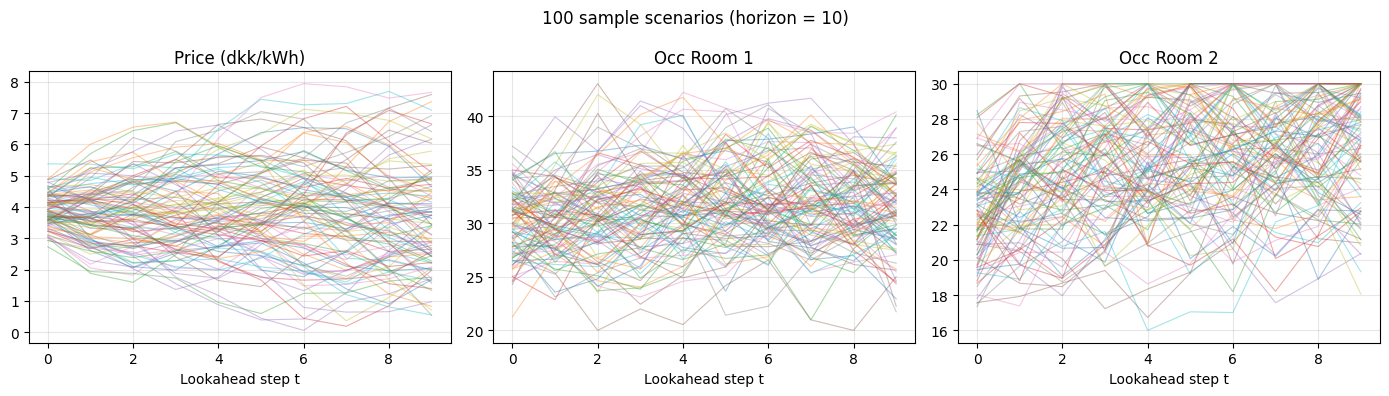

Scenario generation OK.


In [4]:
def generate_scenarios(price_now, price_prev,
                        occ_r1_now, occ_r2_now,
                        horizon, n_scenarios, rng):
    """
    Draw *n_scenarios* independent sample paths over *horizon* steps,
    starting from the current observed state.

    Returns
    -------
    price_dict   : {(t, s): float}        – price at lookahead step t, scenario s
    occ_dict     : {(r, t, s): float}     – occupancy of room r
    hum_occ_dict : {(t, s): float}        – total occupancy (both rooms)
    """
    price_dict   = {}
    occ_dict     = {}
    hum_occ_dict = {}

    for s in range(n_scenarios):
        p_cur,  p_prev  = price_now,   price_prev
        o1_cur, o2_cur  = occ_r1_now,  occ_r2_now

        for t in range(horizon):
            p_next          = price_model(p_cur, p_prev, rng)
            o1_next, o2_next = next_occupancy_levels(o1_cur, o2_cur, rng)

            price_dict[t, s]   = p_next
            occ_dict[1, t, s]  = o1_next
            occ_dict[2, t, s]  = o2_next
            hum_occ_dict[t, s] = o1_next + o2_next

            p_prev, p_cur   = p_cur,  p_next
            o1_cur, o2_cur  = o1_next, o2_next

    return price_dict, occ_dict, hum_occ_dict


# ── Quick visualisation of generated scenarios ────────────────────────────────
_rng_preview = np.random.default_rng(0)
scenarios_to_generate = 100

price_dict, occ_dict, hum_occ_dict = generate_scenarios(
    price_now=4.0, price_prev=4.0,
    occ_r1_now=30.0, occ_r2_now=20.0,
    horizon=10, n_scenarios=scenarios_to_generate,
    rng=_rng_preview
)



fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for s in range(scenarios_to_generate):
    axes[0].plot([price_dict[t, s] for t in range(10)], alpha=0.4, lw=0.8)
    axes[1].plot([occ_dict[1, t, s] for t in range(10)], alpha=0.4, lw=0.8)
    axes[2].plot([occ_dict[2, t, s] for t in range(10)], alpha=0.4, lw=0.8)

for ax, title in zip(axes, ['Price (dkk/kWh)', 'Occ Room 1', 'Occ Room 2']):
    ax.set_xlabel('Lookahead step t')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

fig.suptitle(f'{scenarios_to_generate} sample scenarios (horizon = 10)', fontsize=12)
plt.tight_layout()
plt.show()
print("Scenario generation OK.")


In [28]:
def generate_tree_scenarios(price_now, price_prev, occ_r1_now, occ_r2_now, 
                            branching_factors, rng):
    """
    Generates a tree where branching_factors[t] defines how many 
    children each node at time t produces.
    """
    horizon = len(branching_factors)
    
    # Pre-calculate all scenario paths (indices)
    import itertools
    ranges = [range(b) for b in branching_factors]
    scenario_indices = list(itertools.product(*ranges)) # e.g., (0,0,0), (0,0,1)...
    
    price_dict = {}
    occ_dict = {}
    hum_occ_dict = {}

    # This dictionary will cache the values for each node in the tree
    # Key: (time_step, path_prefix) -> Value: (price, occ1, occ2)
    tree_nodes = {}
    
    # Root state (Stage -1)
    tree_nodes[(-1, ())] = (price_now, price_prev, occ_r1_now, occ_r2_now)

    for t in range(horizon):
        # We only need to generate values for unique prefixes at this time step
        unique_prefixes = set(idx[:t] for idx in scenario_indices)
        
        for prefix in unique_prefixes:
            # Get parent values
            p_cur, p_prev, o1_cur, o2_cur = tree_nodes[(t-1, prefix)]
            
            # Generate N children for this specific parent
            num_children = branching_factors[t]
            for branch_idx in range(num_children):
                current_prefix = prefix + (branch_idx,)
                
                # Draw from your models
                p_next = price_model(p_cur, p_prev, rng)
                o1_next, o2_next = next_occupancy_levels(o1_cur, o2_cur, rng)
                
                # Store node value
                tree_nodes[(t, current_prefix)] = (p_next, p_cur, o1_next, o2_next)

    # Finally, map the tree nodes back to the (t, s) format your model expects
    for s_int, path in enumerate(scenario_indices):
        for t in range(horizon):
            node_val = tree_nodes[(t, path[:t+1])]
            price_dict[t, s_int] = node_val[0]
            occ_dict[1, t, s_int] = node_val[2]
            occ_dict[2, t, s_int] = node_val[3]
            hum_occ_dict[t, s_int] = node_val[2] + node_val[3]

    return price_dict, occ_dict, hum_occ_dict

In [29]:
# Try this configuration:
BRANCHING_FACTORS = [6, 2, 2, 1] 
# Total Scenarios = 24

In [5]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

def cluster_scenarios_tree(price_dict, occ_dict, n_branches, horizon, scenarios_to_generate):
    """
    Builds a scenario tree by recursive conditional K-Means clustering.
    
    At each stage t, clusters the t-th observation within each group of 
    scenarios that shared the same node at t-1.
    
    Returns
    -------
    tree : dict
        node_id -> {
            't'           : int,         # stage (0 = root)
            'parent'      : int or None, # parent node id
            'children'    : list[int],   # child node ids
            'scenarios'   : list[int],   # raw scenario indices in this node
            'centroid'    : dict,        # {'price': float, 'occ1': float, 'occ2': float}
            'cond_prob'   : float,       # P(this node | parent)
            'path_prob'   : float,       # P(root -> this node)
        }
    """

    # --- Root node: contains all scenarios, no centroid needed ---
    tree = {}
    tree[0] = {
        't'         : 0,
        'parent'    : None,
        'children'  : [],
        'scenarios' : list(range(scenarios_to_generate)),
        'centroid'  : None,
        'cond_prob' : 1.0,
        'path_prob' : 1.0,
    }

    node_counter = 1

    # nodes_at_current_stage: list of node_ids whose children we need to create
    nodes_at_current_stage = [0]

    for t in range(horizon):

        nodes_at_next_stage = []

        for parent_id in nodes_at_current_stage:

            parent_node     = tree[parent_id]
            member_scenarios = parent_node['scenarios']
            n_parent        = len(member_scenarios)

            # Gracefully handle nodes with fewer scenarios than n_branches
            k = min(n_branches, n_parent)

            # --- Feature matrix: only the t-th observation ---
            X_t = np.array([
                [price_dict[t, s],
                 occ_dict[1, t, s],
                 occ_dict[2, t, s]]
                for s in member_scenarios
            ])

            scaler = StandardScaler()
            X_t_scaled = scaler.fit_transform(X_t)

            km = KMeans(n_clusters=k, n_init=20, random_state=42)
            km.fit(X_t_scaled)

            centroids_raw = scaler.inverse_transform(km.cluster_centers_)

            # --- Create one child node per cluster ---
            for cluster_label in range(k):

                child_scenarios = [
                    s for s, lbl in zip(member_scenarios, km.labels_)
                    if lbl == cluster_label
                ]

                cond_prob = len(child_scenarios) / n_parent
                path_prob = parent_node['path_prob'] * cond_prob

                c = centroids_raw[cluster_label]
                centroid = {
                    'price' : float(np.clip(c[0],  0, 12)),
                    'occ1'  : float(np.clip(c[1], 20, 50)),
                    'occ2'  : float(np.clip(c[2], 10, 30)),
                }
                centroid['hum_occ'] = centroid['occ1'] + centroid['occ2']

                child_id = node_counter
                tree[child_id] = {
                    't'         : t + 1,
                    'parent'    : parent_id,
                    'children'  : [],
                    'scenarios' : child_scenarios,
                    'centroid'  : centroid,
                    'cond_prob' : cond_prob,
                    'path_prob' : path_prob,
                }
                tree[parent_id]['children'].append(child_id)
                nodes_at_next_stage.append(child_id)
                node_counter += 1

        nodes_at_current_stage = nodes_at_next_stage

    return tree

In [32]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

def cluster_scenarios_tree2(price_dict, occ_dict, branching_factors, horizon):
    """
    Builds a scenario tree by recursive conditional K-Means clustering.
    Supports variable branching factors (non-symmetric trees).
    """

    # --- 1. DYNAMIC SCENARIO EXTRACTION (Fixes the KeyError) ---
    # Extract unique scenario indices directly from the keys of price_dict
    all_scenarios = sorted(list(set(s for (t, s) in price_dict.keys())))

    # --- Root node: contains all scenarios, no centroid needed ---
    tree = {}
    tree[0] = {
        't'         : 0,
        'parent'    : None,
        'children'  : [],
        'scenarios' : all_scenarios,
        'centroid'  : None,
        'cond_prob' : 1.0,
        'path_prob' : 1.0,
    }

    node_counter = 1
    nodes_at_current_stage = [0]

    for t in range(horizon):
        nodes_at_next_stage = []
        
        # --- 2. APPLY VARIABLE BRANCHING ---
        # Get the specific number of branches for this stage t
        if isinstance(branching_factors, (list, tuple)):
            # If the horizon is longer than the provided list, default to 1 branch (deterministic tail)
            current_n_branches = branching_factors[t] if t < len(branching_factors) else 1
        else:
            current_n_branches = branching_factors # Fallback if passed an integer

        for parent_id in nodes_at_current_stage:

            parent_node      = tree[parent_id]
            member_scenarios = parent_node['scenarios']
            n_parent         = len(member_scenarios)

            # Gracefully handle nodes with fewer scenarios than current_n_branches
            k = min(current_n_branches, n_parent)

            # --- Feature matrix: only the t-th observation ---
            X_t = np.array([
                [price_dict[t, s],
                 occ_dict[1, t, s],
                 occ_dict[2, t, s]]
                for s in member_scenarios
            ])

            scaler = StandardScaler()
            X_t_scaled = scaler.fit_transform(X_t)

            km = KMeans(n_clusters=k, n_init=20, random_state=42)
            km.fit(X_t_scaled)

            centroids_raw = scaler.inverse_transform(km.cluster_centers_)

            # --- Create one child node per cluster ---
            for cluster_label in range(k):

                child_scenarios = [
                    s for s, lbl in zip(member_scenarios, km.labels_)
                    if lbl == cluster_label
                ]

                cond_prob = len(child_scenarios) / n_parent
                path_prob = parent_node['path_prob'] * cond_prob

                c = centroids_raw[cluster_label]
                centroid = {
                    'price' : float(np.clip(c[0],  0, 12)),
                    'occ1'  : float(np.clip(c[1], 20, 50)),
                    'occ2'  : float(np.clip(c[2], 10, 30)),
                }
                centroid['hum_occ'] = centroid['occ1'] + centroid['occ2']

                child_id = node_counter
                tree[child_id] = {
                    't'         : t + 1,
                    'parent'    : parent_id,
                    'children'  : [],
                    'scenarios' : child_scenarios,
                    'centroid'  : centroid,
                    'cond_prob' : cond_prob,
                    'path_prob' : path_prob,
                }
                tree[parent_id]['children'].append(child_id)
                nodes_at_next_stage.append(child_id)
                node_counter += 1

        nodes_at_current_stage = nodes_at_next_stage

    return tree

In [6]:
def print_scenario_tree(tree, n_branches, horizon):
    PIPE   = "│   "
    BRANCH = "├── "
    LAST   = "└── "
    BLANK  = "    "

    # ── summary header ──────────────────────────────────────────
    leaf_nodes     = [nid for nid, n in tree.items() if not n['children'] and nid != 0]
    internal_nodes = len(tree) - len(leaf_nodes) - 1  # exclude root

    print("=" * 60)
    print("  Scenario Tree Summary")
    print("=" * 60)
    print(f"  Branches per node  : {n_branches}")
    print(f"  Horizon (stages)   : {horizon}")
    print(f"  Total nodes        : {len(tree)}  (root + {internal_nodes} internal + {len(leaf_nodes)} leaves)")
    print(f"  Scenarios (raw)    : {len(tree[0]['scenarios'])}")
    print(f"  Path prob sum      : {sum(tree[nid]['path_prob'] for nid in leaf_nodes):.4f}  (should be 1.0)")
    print("=" * 60)
    print()

    # ── recursive tree printer ───────────────────────────────────
    def _node_line(node_id, prefix, is_last):
        node      = tree[node_id]
        connector = LAST if is_last else BRANCH

        if node_id == 0:
            print(f"{prefix}{connector}[root]  t=0  all scenarios  S={len(node['scenarios'])}")
        else:
            tag = "[leaf]" if not node['children'] else "[node]"
            c   = node['centroid']
            print(f"{prefix}{connector}{tag}  id={node_id:3d}  t={node['t']}"
                  f"  S={len(node['scenarios']):3d}"
                  f"  cond={node['cond_prob']:.3f}  path={node['path_prob']:.4f}"
                  f"  │  price={c['price']:5.2f}  occ={c['hum_occ']:5.1f}")

        extension = BLANK if is_last else PIPE
        children  = node['children']
        for i, child_id in enumerate(children):
            _node_line(child_id, prefix + extension, is_last=(i == len(children) - 1))

    _node_line(0, prefix="", is_last=True)

    # ── leaf summary table ───────────────────────────────────────
    print()
    print("-" * 60)
    print(f"  {'Leaf id':>7}  {'t':>3}  {'S':>4}  {'path_prob':>9}  {'price':>6}  {'hum_occ':>7}")
    print("-" * 60)
    for nid in leaf_nodes:
        n, c = tree[nid], tree[nid]['centroid']
        print(f"  {nid:>7}  {n['t']:>3}  {len(n['scenarios']):>4}"
              f"  {n['path_prob']:>9.4f}  {c['price']:>6.2f}  {c['hum_occ']:>7.1f}")
    print("-" * 60)
    print(f"  {'SUM':>7}  {'':>3}  {'':>4}  {sum(tree[nid]['path_prob'] for nid in leaf_nodes):>9.4f}")
    print("=" * 60)

# ── Build and print the scenario tree ─────────────────────────────────────────
n_branches = 3
scenario_tree = cluster_scenarios_tree(
    price_dict, occ_dict, n_branches=n_branches,
    horizon=DATA['num_timeslots'], scenarios_to_generate=scenarios_to_generate
)

print_scenario_tree(scenario_tree, n_branches=n_branches, horizon=DATA['num_timeslots'])

  Scenario Tree Summary
  Branches per node  : 3
  Horizon (stages)   : 10
  Total nodes        : 703  (root + 602 internal + 100 leaves)
  Scenarios (raw)    : 100
  Path prob sum      : 1.0000  (should be 1.0)

└── [root]  t=0  all scenarios  S=100
    ├── [node]  id=  1  t=1  S= 37  cond=0.370  path=0.3700  │  price= 4.40  occ= 51.7
    │   ├── [node]  id=  4  t=2  S= 13  cond=0.351  path=0.1300  │  price= 4.22  occ= 54.0
    │   │   ├── [node]  id= 13  t=3  S=  5  cond=0.385  path=0.0500  │  price= 3.82  occ= 51.4
    │   │   │   ├── [node]  id= 40  t=4  S=  2  cond=0.400  path=0.0200  │  price= 3.76  occ= 59.3
    │   │   │   │   ├── [node]  id=106  t=5  S=  1  cond=0.500  path=0.0100  │  price= 3.63  occ= 57.8
    │   │   │   │   │   └── [node]  id=203  t=6  S=  1  cond=1.000  path=0.0100  │  price= 3.46  occ= 56.0
    │   │   │   │   │       └── [node]  id=303  t=7  S=  1  cond=1.000  path=0.0100  │  price= 3.15  occ= 56.7
    │   │   │   │   │           └── [node]  id=403  t=8 

## 4. Tree sanity-check
Build a small tree (`horizon=3, n_branches=3, 60 raw scenarios`) and inspect the exact node structure that the builder will receive.

In [7]:
# ── Build a small but realistic tree ────────────────────────────────────
_rng_dbg = np.random.default_rng(seed=0)
DBG_HORIZON   = 3
DBG_BRANCHES  = 3
DBG_RAW       = 60

price_dict_dbg, occ_dict_dbg, _ = generate_scenarios(
    price_now=4.0, price_prev=4.0,
    occ_r1_now=30.0, occ_r2_now=20.0,
    horizon=DBG_HORIZON, n_scenarios=DBG_RAW,
    rng=_rng_dbg
)

dbg_tree = cluster_scenarios_tree(
    price_dict_dbg, occ_dict_dbg,
    n_branches=DBG_BRANCHES,
    horizon=DBG_HORIZON,
    scenarios_to_generate=DBG_RAW
)

print_scenario_tree(dbg_tree, n_branches=DBG_BRANCHES, horizon=DBG_HORIZON)


  Scenario Tree Summary
  Branches per node  : 3
  Horizon (stages)   : 3
  Total nodes        : 37  (root + 12 internal + 24 leaves)
  Scenarios (raw)    : 60
  Path prob sum      : 1.0000  (should be 1.0)

└── [root]  t=0  all scenarios  S=60
    ├── [node]  id=  1  t=1  S= 14  cond=0.233  path=0.2333  │  price= 3.87  occ= 47.3
    │   ├── [node]  id=  4  t=2  S=  3  cond=0.214  path=0.0500  │  price= 4.50  occ= 47.1
    │   │   ├── [leaf]  id= 13  t=3  S=  1  cond=0.333  path=0.0167  │  price= 5.25  occ= 44.7
    │   │   ├── [leaf]  id= 14  t=3  S=  1  cond=0.333  path=0.0167  │  price= 5.94  occ= 50.4
    │   │   └── [leaf]  id= 15  t=3  S=  1  cond=0.333  path=0.0167  │  price= 2.62  occ= 52.0
    │   ├── [node]  id=  5  t=2  S= 10  cond=0.714  path=0.1667  │  price= 3.77  occ= 52.5
    │   │   ├── [leaf]  id= 16  t=3  S=  4  cond=0.400  path=0.0667  │  price= 3.96  occ= 50.0
    │   │   ├── [leaf]  id= 17  t=3  S=  5  cond=0.500  path=0.0833  │  price= 3.37  occ= 56.8
    │   │  

In [8]:
# ── Classify nodes and verify indexing assumptions ───────────────────────
all_nodes_dbg      = list(dbg_tree.keys())
internal_nodes_dbg = [nid for nid, n in dbg_tree.items() if n['children'] and nid != 0]
leaf_nodes_dbg     = [nid for nid, n in dbg_tree.items() if not n['children'] and nid != 0]

print(f'Root             : {[nid for nid in all_nodes_dbg if dbg_tree[nid]["parent"] is None]}')
print(f'Children of root : {dbg_tree[0]["children"]}')
print(f'Internal nodes   : {internal_nodes_dbg}')
print(f'Leaf nodes       : {leaf_nodes_dbg}')
print()
print('Node details (t, parent, children, centroid_is_None):')
for nid in sorted(all_nodes_dbg):
    n = dbg_tree[nid]
    print(f'  nid={nid:3d}  t={n["t"]}  parent={str(n["parent"]):>4}  '
          f'children={n["children"]}  centroid_None={n["centroid"] is None}')

# ── Assertions ────────────────────────────────────────────────────────────
print()
assert 0 not in internal_nodes_dbg, 'Root should NOT be internal'
assert 0 not in leaf_nodes_dbg,     'Root should NOT be a leaf'
print('Root exclusion from N_int and N_leaf: ✓')

for nid in internal_nodes_dbg:
    assert dbg_tree[nid]['centroid'] is not None, f'Internal node {nid} has None centroid!'
print('All internal nodes have valid centroids: ✓')

total_path = sum(dbg_tree[nid]['path_prob'] for nid in leaf_nodes_dbg)
print(f'Sum of leaf path_probs: {total_path:.6f}  (should be ~1.0): '
      + ('✓' if abs(total_path - 1.0) < 1e-9 else '✗'))


Root             : [0]
Children of root : [1, 2, 3]
Internal nodes   : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Leaf nodes       : [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]

Node details (t, parent, children, centroid_is_None):
  nid=  0  t=0  parent=None  children=[1, 2, 3]  centroid_None=True
  nid=  1  t=1  parent=   0  children=[4, 5, 6]  centroid_None=False
  nid=  2  t=1  parent=   0  children=[7, 8, 9]  centroid_None=False
  nid=  3  t=1  parent=   0  children=[10, 11, 12]  centroid_None=False
  nid=  4  t=2  parent=   1  children=[13, 14, 15]  centroid_None=False
  nid=  5  t=2  parent=   1  children=[16, 17, 18]  centroid_None=False
  nid=  6  t=2  parent=   1  children=[19]  centroid_None=False
  nid=  7  t=2  parent=   2  children=[20, 21, 22]  centroid_None=False
  nid=  8  t=2  parent=   2  children=[23, 24, 25]  centroid_None=False
  nid=  9  t=2  parent=   2  children=[26, 27]  centroid_None=False
  nid= 10  t=2  pare

## 5. Bug 1 – `temp_dynamics` for children of root

**Root cause:** when `pid == 0`, the code correctly sets `dec_node = nid`, but then the constraint body still references `pid` (=0) for `Heat[r, pid]`, `Vent[pid]`, and `occ(r, pid)`. The root is not in `N_int`, so Pyomo raises a `KeyError` during model construction.

**Trace for a stage-1 node `nid` with `pid=0`:**
```
dec_node = nid          # ← correct
return T_in[r,nid] == (
    T_in[r, pid]        # ← pid=0, state var OK (on all N)
    + Zexch*(T_in[other,pid] - T_in[r,pid])  # ← pid=0 OK
    + Zloss*(Tout[t_parent] - T_in[r,pid])   # ← pid=0 OK
    + Zconv * Heat[r, pid]   # ← BUG: Heat indexed on N_int, pid=0 not in N_int
    - Zcool * Vent[pid]      # ← BUG: same
    + Zocc  * occ(r, pid)    # ← BUG: occ() uses O1/O2 on N_int, pid=0 not there
)
```
**Fix:** use `dec_node` (= `nid`) everywhere in the RHS, not `pid`.

In [9]:
# Demonstrate the bug with a minimal Pyomo model
from pyomo.environ import ConcreteModel, Set, Var, Param, Constraint, NonNegativeReals, Binary

# Simulate: root=0, one child nid=1 (pid=0)
fake_tree = {
    0: {'t': 0, 'parent': None, 'children': [1], 'centroid': None, 'path_prob': 1.0},
    1: {'t': 1, 'parent': 0,    'children': [],  'centroid': {'price':4.,'occ1':30.,'occ2':20.,'hum_occ':50.}, 'path_prob': 1.0},
}
internal_fake = [1]
leaf_fake     = [1]  # also a leaf if horizon=1
all_fake      = [0, 1]

m_bug = ConcreteModel()
m_bug.R     = Set(initialize=[1, 2])
m_bug.N     = Set(initialize=all_fake)
m_bug.N_int = Set(initialize=internal_fake)
m_bug.RN_int = m_bug.R * m_bug.N_int

m_bug.Heat  = Var(m_bug.RN_int, domain=NonNegativeReals)
m_bug.Vent  = Var(m_bug.N_int,  domain=Binary)
m_bug.T_in  = Var(m_bug.R * m_bug.N, domain=NonNegativeReals)

occ_param = {1: 30., 2: 20.}  # only indexed on N_int
m_bug.O1 = Param(m_bug.N_int, initialize={1: 30.})

print('--- Testing BUGGY indexing (pid=0) ---')
try:
    # This mimics the buggy code: uses pid=0 instead of nid=1
    pid = 0
    nid = 1
    _ = m_bug.Heat[1, pid]   # pid=0 not in N_int
    print('  m_bug.Heat[1, 0]: no error (unexpected)')
except Exception as e:
    print(f'  m_bug.Heat[1, 0] → {type(e).__name__}: {e}')

try:
    _ = m_bug.O1[pid]         # pid=0 not in N_int
    print('  m_bug.O1[0]: no error (unexpected)')
except Exception as e:
    print(f'  m_bug.O1[0]   → {type(e).__name__}: {e}')

print()
print('--- Testing FIXED indexing (nid=1) ---')
try:
    _ = m_bug.Heat[1, nid]   # nid=1 IS in N_int
    print('  m_bug.Heat[1, 1]: ✓ OK')
except Exception as e:
    print(f'  m_bug.Heat[1, 1] → {type(e).__name__}: {e}')

try:
    _ = m_bug.O1[nid]         # nid=1 IS in N_int
    print('  m_bug.O1[1]  : ✓ OK')
except Exception as e:
    print(f'  m_bug.O1[1]  → {type(e).__name__}: {e}')


--- Testing BUGGY indexing (pid=0) ---
  m_bug.Heat[1, 0] → KeyError: "Index '(1, 0)' is not valid for indexed component 'Heat'"
  m_bug.O1[0]   → KeyError: "Index '0' is not valid for indexed component 'O1'"

--- Testing FIXED indexing (nid=1) ---
  m_bug.Heat[1, 1]: ✓ OK
  m_bug.O1[1]  : ✓ OK


## 6. Bug 3 – `_path_to_root` coverage check

Verify that for each leaf the path returned covers all internal nodes on the path (stages 1 through H-1) and correctly excludes the root and the leaf itself.

In [10]:
def _path_to_root_orig(tree, leaf_id):
    path = []
    nid  = tree[leaf_id]['parent']
    while nid is not None and tree[nid]['parent'] is not None:
        path.append(nid)
        nid = tree[nid]['parent']
    return path

print('Path-to-root for each leaf (original):')
for leaf in leaf_nodes_dbg:
    path = _path_to_root_orig(dbg_tree, leaf)
    stages = [dbg_tree[n]['t'] for n in path]
    print(f'  leaf {leaf:3d} (t={dbg_tree[leaf]["t"]}) → path {path}  stages {stages}')

# Expected: for H=3, leaf at t=3 should have path covering t=1 and t=2 nodes
# If H=3 and branches=3, children of root are at t=1, their children at t=2, leaves at t=3
# _path_to_root starts at leaf['parent'] (t=2), then its parent (t=1),
# then t=1's parent is root (parent=None), loop stops before adding root.
# So path = [t=2 node, t=1 node] — correct.
print()
expected_stages = set(range(1, DBG_HORIZON))  # {1, 2}
for leaf in leaf_nodes_dbg:
    path = _path_to_root_orig(dbg_tree, leaf)
    stages = set(dbg_tree[n]['t'] for n in path)
    ok = stages == expected_stages
    print(f'  leaf {leaf:3d}: stages covered = {sorted(stages)}  '
          f'expected {sorted(expected_stages)}  {"✓" if ok else "✗"}')


Path-to-root for each leaf (original):
  leaf  13 (t=3) → path [4, 1]  stages [2, 1]
  leaf  14 (t=3) → path [4, 1]  stages [2, 1]
  leaf  15 (t=3) → path [4, 1]  stages [2, 1]
  leaf  16 (t=3) → path [5, 1]  stages [2, 1]
  leaf  17 (t=3) → path [5, 1]  stages [2, 1]
  leaf  18 (t=3) → path [5, 1]  stages [2, 1]
  leaf  19 (t=3) → path [6, 1]  stages [2, 1]
  leaf  20 (t=3) → path [7, 2]  stages [2, 1]
  leaf  21 (t=3) → path [7, 2]  stages [2, 1]
  leaf  22 (t=3) → path [7, 2]  stages [2, 1]
  leaf  23 (t=3) → path [8, 2]  stages [2, 1]
  leaf  24 (t=3) → path [8, 2]  stages [2, 1]
  leaf  25 (t=3) → path [8, 2]  stages [2, 1]
  leaf  26 (t=3) → path [9, 2]  stages [2, 1]
  leaf  27 (t=3) → path [9, 2]  stages [2, 1]
  leaf  28 (t=3) → path [10, 3]  stages [2, 1]
  leaf  29 (t=3) → path [10, 3]  stages [2, 1]
  leaf  30 (t=3) → path [10, 3]  stages [2, 1]
  leaf  31 (t=3) → path [11, 3]  stages [2, 1]
  leaf  32 (t=3) → path [11, 3]  stages [2, 1]
  leaf  33 (t=3) → path [11, 3]  sta

## 7. Corrected `build_multisp_model`

Changes from original, clearly marked:
- **FIX-1** (`temp_dynamics`): for children of root (`pid == 0`), use `nid` (= `dec_node`) in the RHS for `Heat`, `Vent`, and `occ()` instead of `pid`.
- **FIX-2** (`_path_to_root`): add stage-1 node to path by continuing the walk one extra step (stop when `nid` becomes root itself, not its children's parent).
- **FIX-3** (comments): clarify leaf node semantics throughout.
- All other logic is unchanged.

In [19]:
def _path_to_root(tree, leaf_id):
    """
    Return list of internal node ids from leaf back to (but not including) root.
    These are the nodes where decisions were made on this scenario's path.
    """
    path = []
    nid  = tree[leaf_id]['parent']          # start at leaf's parent
    while nid is not None and tree[nid]['parent'] is not None:
        path.append(nid)
        nid = tree[nid]['parent']
    # FIX-2: also include nid itself if it's a stage-1 node
    # (its parent is root which has parent=None, so loop exits without appending it)
    if nid is not None and tree[nid]['parent'] is None and nid != 0:
        path.append(nid)
    return path


def _descendants_chain(tree, nid, L):
    """
    Return up to L successive nodes starting from nid, following the
    first child at each step. Used for the minimum-uptime window.
    """
    chain   = [nid]
    current = nid
    for _ in range(L - 1):
        children = tree[current]['children']
        if not children:
            break
        current = children[0]
        chain.append(current)
    return chain


def build_multisp_model(current_state, tree, horizon):
    """
    Build the multi-stage stochastic MILP indexed on scenario-tree nodes.

    Parameters
    ----------
    current_state : dict  (T_in_r1, T_in_r2, humidity, vent_prev, vent_on_count)
    tree          : dict  node_id -> {t, parent, children, centroid, cond_prob, path_prob}
    horizon       : int

    Returns
    -------
    Pyomo ConcreteModel (unsolved)
    """
    d = DATA
    M = 200.0

    T_init = {1: current_state['T_in_r1'], 2: current_state['T_in_r2']}
    H_init = current_state['humidity']
    v_prev = int(current_state['vent_prev'])
    v_on_h = int(current_state.get('vent_on_count', 0))

    # ── Node sets ─────────────────────────────────────────────────────────────
    all_nodes      = list(tree.keys())
    internal_nodes = [nid for nid, n in tree.items() if n['children'] and nid != 0]
    leaf_nodes     = [nid for nid, n in tree.items() if not n['children'] and nid != 0]
    internal_set   = set(internal_nodes)
    leaf_set       = set(leaf_nodes)

    # ── Exogenous data dicts (keyed by internal node id only) ─────────────────
    # Root (id=0) has centroid=None and is excluded automatically.
    price_by_node  = {nid: tree[nid]['centroid']['price']
                      for nid in internal_nodes if tree[nid]['centroid'] is not None}
    occ1_by_node   = {nid: tree[nid]['centroid']['occ1']
                      for nid in internal_nodes if tree[nid]['centroid'] is not None}
    occ2_by_node   = {nid: tree[nid]['centroid']['occ2']
                      for nid in internal_nodes if tree[nid]['centroid'] is not None}
    humocc_by_node = {nid: tree[nid]['centroid']['hum_occ']
                      for nid in internal_nodes if tree[nid]['centroid'] is not None}

    path_prob_by_leaf = {nid: tree[nid]['path_prob'] for nid in leaf_nodes}

    m = ConcreteModel()

    # ── Sets ──────────────────────────────────────────────────────────────────
    m.R      = Set(initialize=[1, 2])
    m.N      = Set(initialize=all_nodes)
    m.N_int  = Set(initialize=internal_nodes)
    m.N_leaf = Set(initialize=leaf_nodes)
    m.RN_int = m.R * m.N_int

    # ── Physical parameters ───────────────────────────────────────────────────
    m.Pr    = Param(initialize=d['heating_max_power'])
    m.Zexch = Param(initialize=d['heat_exchange_coeff'])
    m.Zconv = Param(initialize=d['heating_efficiency_coeff'])
    m.Zloss = Param(initialize=d['thermal_loss_coeff'])
    m.Zcool = Param(initialize=d['heat_vent_coeff'])
    m.Zocc  = Param(initialize=d['heat_occupancy_coeff'])
    m.Tmin  = Param(initialize=d['temp_min_comfort_threshold'])
    m.Tok   = Param(initialize=d['temp_OK_threshold'])
    m.Thigh = Param(initialize=d['temp_max_comfort_threshold'])
    m.Hhigh = Param(initialize=d['humidity_threshold'])
    m.Pvent = Param(initialize=d['ventilation_power'])
    m.Hocc  = Param(initialize=d['humidity_occupancy_coeff'])
    m.Hvent = Param(initialize=d['humidity_vent_coeff'])
    m.Tout  = Param(range(horizon),
                    initialize={t: d['outdoor_temperature'][t] for t in range(horizon)})

    m.prices = Param(m.N_int, initialize=price_by_node)
    m.HumOcc = Param(m.N_int, initialize=humocc_by_node)
    m.O1     = Param(m.N_int, initialize=occ1_by_node)
    m.O2     = Param(m.N_int, initialize=occ2_by_node)
    m.pi     = Param(m.N_leaf, initialize=path_prob_by_leaf)

    # ── Decision variables (on internal nodes only) ───────────────────────────
    m.Heat = Var(m.RN_int, domain=NonNegativeReals, bounds=(0, d['heating_max_power']))
    m.Vent = Var(m.N_int,  domain=Binary)
    m.Uon  = Var(m.N_int,  domain=Binary)
    m.Uoff = Var(m.N_int,  domain=Binary)

    m.u = Var(m.RN_int, domain=Binary)
    m.w = Var(m.RN_int, domain=Binary)
    m.y = Var(m.RN_int, domain=Binary)

    # ── State variables (on ALL nodes) ────────────────────────────────────────
    m.T_in = Var(m.R * m.N, domain=NonNegativeReals)
    m.Hum  = Var(m.N,        domain=NonNegativeReals)

    # ── Helper: occupancy lookup (internal nodes only) ────────────────────────
    def occ(r, nid):
        return m.O1[nid] if r == 1 else m.O2[nid]

    # ── Temperature dynamics ──────────────────────────────────────────────────
    # Node categories:
    #   ROOT (nid=0)             : initialise from current_state
    #   CHILD-OF-ROOT (pid=0)    : T_in[r,nid] driven by decisions AT nid, state from root
    #   INTERNAL (pid internal)  : driven by decisions AT pid, state from pid
    #   LEAF (pid internal)      : same as INTERNAL (no decision at leaf)
    def temp_dynamics(m, r, nid):
        if nid == 0:
            return m.T_in[r, nid] == T_init[r]

        pid     = tree[nid]['parent']
        other_r = 2 if r == 1 else 1

        if pid == 0:
            # ── FIX-1 ────────────────────────────────────────────────────────
            # Parent is root → decisions made AT nid (not at pid which has no vars).
            # State flows FROM root (pid=0), decisions come FROM nid.
            # nid is internal (it has children or is a stage-1 node with data).
            # If nid is a leaf (horizon=1 edge case), skip decision terms.
            t_root = tree[0]['t']   # = 0
            if nid in leaf_set:
                # Leaf whose parent is root (horizon=1): no decision terms
                return m.T_in[r, nid] == (
                    m.T_in[r, 0]
                    + m.Zexch * (m.T_in[other_r, 0] - m.T_in[r, 0])
                    + m.Zloss * (m.Tout[t_root]      - m.T_in[r, 0])
                )
            # Normal stage-1 internal node
            return m.T_in[r, nid] == (
                m.T_in[r, 0]
                + m.Zexch * (m.T_in[other_r, 0] - m.T_in[r, 0])
                + m.Zloss * (m.Tout[t_root]      - m.T_in[r, 0])
                + m.Zconv * m.Heat[r, nid]   # FIX-1: nid, not pid
                - m.Zcool * m.Vent[nid]       # FIX-1: nid, not pid
                + m.Zocc  * occ(r, nid)       # FIX-1: nid, not pid
            )

        # General case: pid is a non-root internal node
        t_parent = tree[pid]['t']
        if nid in leaf_set:
            # Leaf: state from pid, no decision terms (leaf has no Heat/Vent)
            return m.T_in[r, nid] == (
                m.T_in[r, pid]
                + m.Zexch * (m.T_in[other_r, pid] - m.T_in[r, pid])
                + m.Zloss * (m.Tout[t_parent]      - m.T_in[r, pid])
                + m.Zconv * m.Heat[r, pid]
                - m.Zcool * m.Vent[pid]
                + m.Zocc  * occ(r, pid)
            )
        # Internal non-root: decisions at pid propagate into nid's initial state
        return m.T_in[r, nid] == (
            m.T_in[r, pid]
            + m.Zexch * (m.T_in[other_r, pid] - m.T_in[r, pid])
            + m.Zloss * (m.Tout[t_parent]      - m.T_in[r, pid])
            + m.Zconv * m.Heat[r, pid]
            - m.Zcool * m.Vent[pid]
            + m.Zocc  * occ(r, pid)
        )
    m.TempDyn = Constraint(m.R * m.N, rule=temp_dynamics)

    # ── Humidity dynamics ─────────────────────────────────────────────────────
    def hum_dynamics(m, nid):
        if nid == 0:
            return m.Hum[nid] == H_init
        pid = tree[nid]['parent']
        if pid == 0:
            if nid in leaf_set:
                # Leaf whose parent is root: no decision terms
                return m.Hum[nid] == m.Hum[0]
            return m.Hum[nid] == (
                m.Hum[0]
                - m.Hvent * m.Vent[nid]
                + m.Hocc  * m.HumOcc[nid]
            )
        # General case: decisions at pid flow into nid
        return m.Hum[nid] == (
            m.Hum[pid]
            - m.Hvent * m.Vent[pid]
            + m.Hocc  * m.HumOcc[pid]
        )
    m.HumDyn = Constraint(m.N, rule=hum_dynamics)

    # ── Overrule controllers (internal nodes only) ────────────────────────────
    def u_activation(m, r, nid):
        return m.T_in[r, nid] >= m.Tmin - M * m.u[r, nid]
    m.UActivation = Constraint(m.RN_int, rule=u_activation)

    def w_deactivation(m, r, nid):
        return m.T_in[r, nid] >= m.Tok - M * (1 - m.w[r, nid])
    m.WDeactivation = Constraint(m.RN_int, rule=w_deactivation)

    def u_persistence(m, r, nid):
        pid = tree[nid]['parent']
        if pid is None or pid == 0:
            m.u[r, nid].fix(0)
            m.w[r, nid].fix(0)
            return Constraint.Skip
        return m.u[r, nid] >= m.u[r, pid] - m.w[r, nid]
    m.UPersistence = Constraint(m.RN_int, rule=u_persistence)

    def heat_max_when_overrule(m, r, nid):
        return m.Heat[r, nid] >= m.Pr * m.u[r, nid]
    m.HeatMaxOverrule = Constraint(m.RN_int, rule=heat_max_when_overrule)

    def y_activation(m, r, nid):
        return m.T_in[r, nid] <= m.Thigh + M * m.y[r, nid]
    m.YActivation = Constraint(m.RN_int, rule=y_activation)

    def heat_off_when_overrule(m, r, nid):
        return m.Heat[r, nid] <= m.Pr * (1 - m.y[r, nid])
    m.HeatOffOverrule = Constraint(m.RN_int, rule=heat_off_when_overrule)

    def vent_humidity_overrule(m, nid):
        return m.Hum[nid] <= m.Hhigh + M * m.Vent[nid]
    m.VentHumOverrule = Constraint(m.N_int, rule=vent_humidity_overrule)

    # ── Ventilation inertia ───────────────────────────────────────────────────
    def on_off_exclusivity(m, nid):
        return m.Uon[nid] + m.Uoff[nid] <= 1
    m.OnOffExcl = Constraint(m.N_int, rule=on_off_exclusivity)

    def uoff_bound(m, nid):
        return m.Uoff[nid] <= 1 - m.Vent[nid]
    m.UoffBound = Constraint(m.N_int, rule=uoff_bound)

    def uon_bound(m, nid):
        return m.Uon[nid] <= 1 - m.Vent[nid]
    m.UonBound = Constraint(m.N_int, rule=uon_bound)

    def min_uptime(m, nid):
        L     = d['vent_min_up_time']
        chain = [k for k in _descendants_chain(tree, nid, L) if k in internal_set]
        pid   = tree[nid]['parent']
        v_p   = v_prev if (pid is None or pid == 0) else m.Vent[pid]
        return sum(m.Vent[k] for k in chain) >= len(chain) * (m.Vent[nid] - v_p)
    m.MinUptime = Constraint(m.N_int, rule=min_uptime)

    # Carry-over inertia from previous real hours
    if v_prev == 1 and v_on_h < 3:
        forced_on = 3 - v_on_h
        for nid in internal_nodes:
            if tree[nid]['t'] <= forced_on:
                m.Vent[nid].fix(1)

    # ── Objective: E[cost along each path] ───────────────────────────────────
    def objective(m):
        return sum(
            m.pi[leaf] * sum(
                m.prices[nid] * (
                    sum(m.Heat[r, nid] for r in m.R)
                    + m.Vent[nid] * m.Pvent
                )
                for nid in _path_to_root(tree, leaf)
            )
            for leaf in leaf_nodes
        )
    m.obj = Objective(rule=objective, sense=minimize)
    return m


print("build_multisp_model() (fixed) defined.")


build_multisp_model() (fixed) defined.


## 8. Construction test — build the model without solving

We verify that Pyomo can construct all sets, params, variables, and constraints without raising `KeyError` or index errors. No solver required.

In [20]:
# ── Build the corrected model on the debug tree ──────────────────────────
dbg_state = {
    'T_in_r1'      : 21.0,
    'T_in_r2'      : 21.0,
    'humidity'     : 40.0,
    'vent_prev'    : 0,
    'vent_on_count': 0,
}

try:
    m_fixed = build_multisp_model(dbg_state, dbg_tree, DBG_HORIZON)
    print('Model construction: ✓  No index errors')
    print(f'  Variables : {sum(1 for _ in m_fixed.component_data_objects(Var))} entries')
    print(f'  Constraints: {sum(1 for _ in m_fixed.component_data_objects(Constraint))} entries')
except Exception as e:
    import traceback
    print(f'Model construction FAILED:')
    traceback.print_exc()


Model construction: ✓  No index errors
  Variables : 243 entries
  Constraints: 309 entries


In [21]:
# ── Check path_to_root coverage with the fix ────────────────────────────
print('Path-to-root for each leaf (fixed):')
for leaf in leaf_nodes_dbg:
    path = _path_to_root(dbg_tree, leaf)
    stages = [dbg_tree[n]['t'] for n in path]
    ok = sorted(stages) == list(range(1, DBG_HORIZON))
    print(f'  leaf {leaf:3d} (t={dbg_tree[leaf]["t"]}) → stages {sorted(stages)} '
          f'  {"✓" if ok else "✗"}')

# Verify objective sum makes sense
from pyomo.environ import value
print()
print('Objective path-cost terms covered per leaf:')
for leaf in leaf_nodes_dbg:
    path = _path_to_root(dbg_tree, leaf)
    print(f'  leaf {leaf:3d}: {len(path)} decision nodes on path')


Path-to-root for each leaf (fixed):
  leaf  13 (t=3) → stages [1, 2]   ✓
  leaf  14 (t=3) → stages [1, 2]   ✓
  leaf  15 (t=3) → stages [1, 2]   ✓
  leaf  16 (t=3) → stages [1, 2]   ✓
  leaf  17 (t=3) → stages [1, 2]   ✓
  leaf  18 (t=3) → stages [1, 2]   ✓
  leaf  19 (t=3) → stages [1, 2]   ✓
  leaf  20 (t=3) → stages [1, 2]   ✓
  leaf  21 (t=3) → stages [1, 2]   ✓
  leaf  22 (t=3) → stages [1, 2]   ✓
  leaf  23 (t=3) → stages [1, 2]   ✓
  leaf  24 (t=3) → stages [1, 2]   ✓
  leaf  25 (t=3) → stages [1, 2]   ✓
  leaf  26 (t=3) → stages [1, 2]   ✓
  leaf  27 (t=3) → stages [1, 2]   ✓
  leaf  28 (t=3) → stages [1, 2]   ✓
  leaf  29 (t=3) → stages [1, 2]   ✓
  leaf  30 (t=3) → stages [1, 2]   ✓
  leaf  31 (t=3) → stages [1, 2]   ✓
  leaf  32 (t=3) → stages [1, 2]   ✓
  leaf  33 (t=3) → stages [1, 2]   ✓
  leaf  34 (t=3) → stages [1, 2]   ✓
  leaf  35 (t=3) → stages [1, 2]   ✓
  leaf  36 (t=3) → stages [1, 2]   ✓

Objective path-cost terms covered per leaf:
  leaf  13: 2 decision nodes on

## 9. Solve smoke test

Solve the debug model with Gurobi and verify that first-stage decisions are within bounds and all scenario-1 nodes agree (structural non-anticipativity).

In [22]:
from pyomo.opt import TerminationCondition

solver = SolverFactory('gurobi')
solver.options['TimeLimit'] = 30
solver.options['MIPGap']   = 0.01

result = solver.solve(m_fixed, tee=False)

tc = result.solver.termination_condition
print(f'Termination condition : {tc}')
assert tc in (TerminationCondition.optimal, TerminationCondition.feasible,
              TerminationCondition.maxTimeLimit), f'Unexpected: {tc}'

# ── First-stage decisions ─────────────────────────────────────────────────────
# In multi-stage SP, NAC is STRUCTURAL: each node has exactly one variable,
# so scenarios sharing a node share the same decision automatically.
# Stage-1 nodes are DISTINCT branches (each saw a different centroid),
# so Heat[r, node_A] != Heat[r, node_B] is correct and expected — do NOT assert equality.

stage1_nodes = dbg_tree[0]['children']
print()
print('Stage-1 node decisions (branches diverge here — differences are correct):')
for r in [1, 2]:
    heats = [float(value(m_fixed.Heat[r, nid])) for nid in stage1_nodes]
    print(f'  Heat room {r}: {[f"{h:.3f}" for h in heats]}')
    for h in heats:
        assert 0.0 - 1e-6 <= h <= DATA['heating_max_power'] + 1e-6, f'Heat[{r}]={h} out of bounds'
vents = [int(round(float(value(m_fixed.Vent[nid])))) for nid in stage1_nodes]
print(f'  Vent      : {vents}')
for v in vents:
    assert v in (0, 1), f'Vent={v} not binary'

print()
print('Bound checks on all stage-1 decisions: ✓')
print(f'Objective value: {value(m_fixed.obj):.4f} dkk')

# ── Policy decision = first child of root ─────────────────────────────────────
pr_max = DATA['heating_max_power']
d0 = stage1_nodes[0]
p1 = float(np.clip(value(m_fixed.Heat[1, d0]), 0, pr_max))
p2 = float(np.clip(value(m_fixed.Heat[2, d0]), 0, pr_max))
v  = int(round(float(value(m_fixed.Vent[d0]))))
print(f'\nPolicy implements decision from node {d0} (first child of root):')
print(f'  Heat_r1={p1:.3f} kW  Heat_r2={p2:.3f} kW  Vent={v}')

Termination condition : optimal

Stage-1 node decisions (branches diverge here — differences are correct):
  Heat room 1: ['0.246', '0.179', '0.154']
  Heat room 2: ['0.389', '0.322', '0.336']
  Vent      : [0, 0, 0]

Bound checks on all stage-1 decisions: ✓
Objective value: 2.1032 dkk

Policy implements decision from node 1 (first child of root):
  Heat_r1=0.246 kW  Heat_r2=0.389 kW  Vent=0


## 10. Corrected `multi_SP_policy`

Drop-in replacement — same signature, uses the fixed builder.

In [33]:
# ── Hyper-parameters ──────────────────────────────────────────────────────
HORIZON_MULTI = 3    # lookahead steps (≥ 3 due to vent inertia constraint)
GEN_SCENARIOS = 100  # raw Monte Carlo paths (before tree clustering)
N_BRANCHES    = 3    # branches per node in the scenario tree

_rng = np.random.default_rng(seed=22)

initial_state = {
    't'            : 0,
    'T_in_r1'      : DATA['initial_temperature'],
    'T_in_r2'      : DATA['initial_temperature'],
    'humidity'     : DATA['initial_humidity'],
    'vent_status'  : 0,
    'vent_prev'    : 0,
    'vent_on_count': 0,
    'price_now'    : 4.0,
    'price_prev'   : None,
    'occ_r1'       : 30,
    'occ_r2'       : 20,
}


def multi_SP_policy(state, gen_data):
    """
    Multi-stage stochastic programming policy for the restaurant HVAC system.

    Returns
    -------
    (heat_r1, heat_r2, vent) : (float, float, int)
    """
    t = state['t']
    remaining = DATA['num_timeslots'] - t
    horizon   = min(HORIZON_MULTI, remaining)

    if horizon <= 0:
        return 0.0, 0.0, 0

    p_prev = state['price_prev'] if state['price_prev'] is not None else 4.0

    # ── Generate raw scenarios ────────────────────────────────────────────────
    price_dict, occ_dict, _ = generate_tree_scenarios(
        price_now   = gen_data[0][t],
        price_prev  = p_prev,
        occ_r1_now  = gen_data[1][t],
        occ_r2_now  = gen_data[2][t],
        branching_factors = BRANCHING_FACTORS,
        rng         = _rng
    )

    # ── Build scenario tree ───────────────────────────────────────────────────
    tree = cluster_scenarios_tree2(
        price_dict, occ_dict,
        branching_factors = BRANCHING_FACTORS,
        horizon             = horizon,
    )

    # ── Guard: if all children of root are leaves, no Heat/Vent vars exist ────
    # This happens when horizon is so short that stage-1 nodes have no children.
    # Fall back to a deterministic decision using the first child's centroid.
    stage1_nodes   = tree[0]['children']
    internal_nodes = [nid for nid, n in tree.items() if n['children'] and nid != 0]
    if not internal_nodes:
        # No branching possible: use centroid of first stage-1 node directly
        # (cheapest feasible action — heat nothing, vent off)
        return 0.0, 0.0, 0


    current_state = {
        'T_in_r1'      : state['T_in_r1'],
        'T_in_r2'      : state['T_in_r2'],
        'humidity'     : state['humidity'],
        'vent_prev'    : state['vent_status'],
        'vent_on_count': state['vent_on_count'],
    }

    # ── Solve ─────────────────────────────────────────────────────────────────
    model  = build_multisp_model(current_state, tree, horizon)
    solver = SolverFactory('gurobi')
    solver.options['TimeLimit'] = 12
    solver.options['MIPGap']   = 0.02
    solver.solve(model, tee=False)

    # ── Extract first-stage decision (from any child of root) ─────────────────
    decision_node = next(nid for nid in stage1_nodes if nid in set(internal_nodes))
    p1 = float(value(model.Heat[1, decision_node]))
    p2 = float(value(model.Heat[2, decision_node]))
    v  = int(round(float(value(model.Vent[decision_node]))))

    pr_max = DATA['heating_max_power']
    p1 = float(np.clip(p1, 0.0, pr_max))
    p2 = float(np.clip(p2, 0.0, pr_max))
    v  = int(np.clip(v,  0, 1))

    return p1, p2, v


print("multi_SP_policy() (fixed) defined.")
print(f"  Horizon  = {HORIZON_MULTI} steps")
print(f"  Branches = {N_BRANCHES} per node")
print(f"  Raw scen = {GEN_SCENARIOS}")


multi_SP_policy() (fixed) defined.
  Horizon  = 3 steps
  Branches = 3 per node
  Raw scen = 100


## 11. `apply_dynamics` (unchanged)

In [17]:
# Apply Dynamics to get next state from first-stage decisions
def apply_dynamics(state, decisions, gen_data):
    """
    Advance the real system state by one timestep.

    Parameters
    ----------
    state : dict with keys
        T_in_r1       – room 1 temperature (°C)
        T_in_r2       – room 2 temperature (°C)
        humidity      – humidity level (%)
        vent_prev     – ventilation status at current t (0 or 1)
        vent_on_count – consecutive hours ventilation has been ON
        t             – current hour index (0-based)
        occ_r1        – room 1 occupancy at current t
        occ_r2        – room 2 occupancy at current t

    decisions : dict with keys
        p1  – heating power room 1 (kW)
        p2  – heating power room 2 (kW)
        v   – ventilation (0 or 1)

    Returns
    -------
    next_state : dict with same keys as state, advanced by one step.
                occ_r1 and occ_r2 are set to None — filled by environment.
    """
    d    = get_fixed_data()
    t    = state['t']
    p1   = decisions[0]
    p2   = decisions[1]
    v    = decisions[2]
    o1   = gen_data[1][t]
    o2   = gen_data[2][t]
    T1   = state['T_in_r1']
    T2   = state['T_in_r2']
    H    = state['humidity']
    Tout = d['outdoor_temperature'][t]

    # ── Temperature dynamics ──────────────────────────────────────────────────
    T1_next = (T1
            + d['heat_exchange_coeff']      * (T2   - T1)
            + d['thermal_loss_coeff']       * (Tout - T1)
            + d['heating_efficiency_coeff'] * p1
            - d['heat_vent_coeff']          * v
            + d['heat_occupancy_coeff']     * o1)

    T2_next = (T2
            + d['heat_exchange_coeff']      * (T1   - T2)
            + d['thermal_loss_coeff']       * (Tout - T2)
            + d['heating_efficiency_coeff'] * p2
            - d['heat_vent_coeff']          * v
            + d['heat_occupancy_coeff']     * o2)

    # ── Humidity dynamics ─────────────────────────────────────────────────────
    H_next = max(0.0,
                H
                - d['humidity_vent_coeff']      * v
                + d['humidity_occupancy_coeff'] * (o1 + o2))

    # ── Ventilation inertia counter ───────────────────────────────────────────
    if v == 1 and state['vent_status'] == 0:
        vent_on_count_next = 1
    elif v == 1:
        vent_on_count_next = min(state['vent_on_count'] + 1, 3)
    else:
        vent_on_count_next = 0 

    return {
        'T_in_r1'      : T1_next,
        'T_in_r2'      : T2_next,
        'humidity'     : H_next,
        'vent_status'    : v,
        'vent_on_count': vent_on_count_next,
        't'            : t + 1,
        'occ_r1'       : None,   # filled by environment at next step
        'occ_r2'       : None,   # filled by environment at next step
        'price_now'    : None,
        'price_prev'   : state['price_now'],  # for next step's scenario generation
    } #returns next_state dictionary


## 12. Full 10-step rollout

Run `multi_SP_policy` for all 10 hours and record states/decisions.

In [34]:
_rng = np.random.default_rng(seed=22)

sample_prices = [float(np.clip(_rng.normal(4, 1), 0, 12)) for _ in range(10)]
sample_occ_r1 = [float(np.clip(_rng.normal(30, 5), 20, 50)) for _ in range(10)]
sample_occ_r2 = [float(np.clip(_rng.normal(20, 4), 10, 30)) for _ in range(10)]
gen_data = sample_prices, sample_occ_r1, sample_occ_r2

log = {k: [] for k in ['t','T1','T2','H','p1','p2','v','price','cost_t']}
total_cost = 0.0
d_fixed    = get_fixed_data()

state = initial_state.copy()
for i in range(10):
    state['price_now'] = gen_data[0][i]
    state['occ_r1']    = gen_data[1][i]
    state['occ_r2']    = gen_data[2][i]

    decisions = multi_SP_policy(state, gen_data)

    cost = (decisions[0] + decisions[1] + decisions[2] * d_fixed['ventilation_power']) * gen_data[0][i]
    total_cost += cost

    log['t'].append(i)
    log['T1'].append(state['T_in_r1'])
    log['T2'].append(state['T_in_r2'])
    log['H'].append(state['humidity'])
    log['p1'].append(decisions[0])
    log['p2'].append(decisions[1])
    log['v'].append(decisions[2])
    log['price'].append(gen_data[0][i])
    log['cost_t'].append(cost)

    state = apply_dynamics(state, decisions, gen_data)

log['total_cost'] = total_cost
print(f'Total cost: {total_cost:.3f} dkk')


Total cost: 141.655 dkk


## 13. Result visualisation

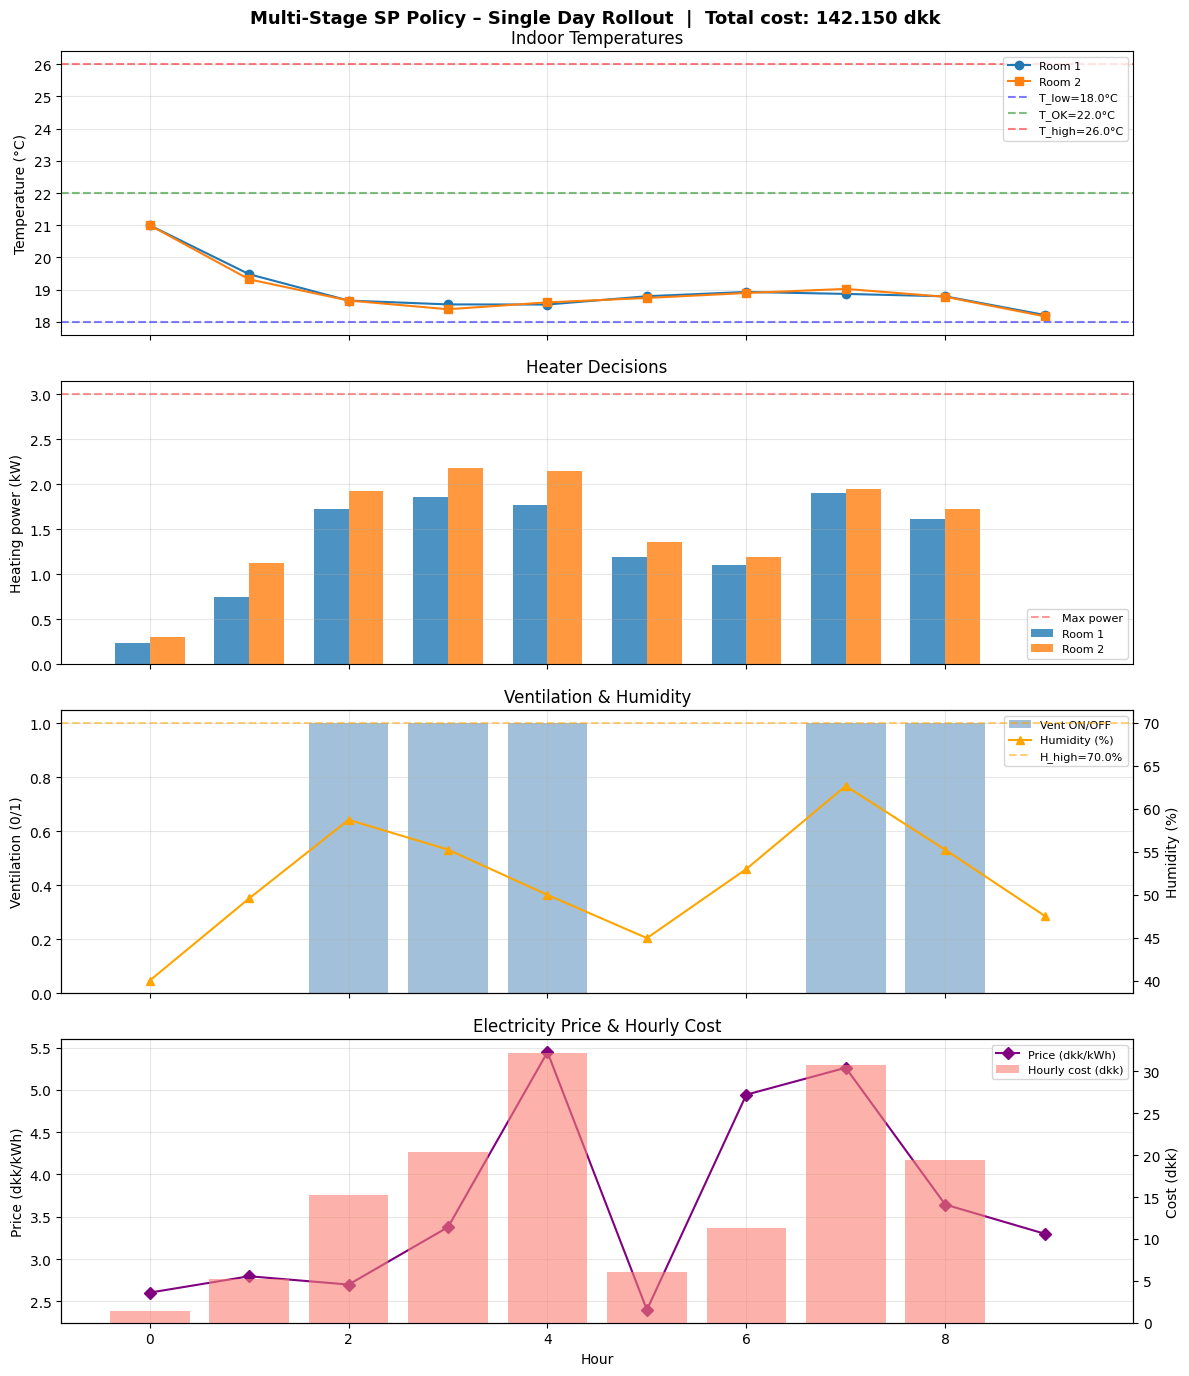

In [27]:
fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)
T_range = log['t']

axes[0].plot(T_range, log['T1'], marker='o', label='Room 1')
axes[0].plot(T_range, log['T2'], marker='s', label='Room 2')
for val, ls, col, lbl in [
    (DATA['temp_min_comfort_threshold'], '--', 'blue',  'T_low'),
    (DATA['temp_OK_threshold'],          '--', 'green', 'T_OK'),
    (DATA['temp_max_comfort_threshold'], '--', 'red',   'T_high'),
]:
    axes[0].axhline(val, ls=ls, color=col, alpha=0.5, label=f'{lbl}={val}°C')
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('Indoor Temperatures')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

w = 0.35
axes[1].bar([x - w/2 for x in T_range], log['p1'], width=w, label='Room 1', alpha=0.8)
axes[1].bar([x + w/2 for x in T_range], log['p2'], width=w, label='Room 2', alpha=0.8)
axes[1].axhline(DATA['heating_max_power'], ls='--', color='red', alpha=0.4, label='Max power')
axes[1].set_ylabel('Heating power (kW)')
axes[1].set_title('Heater Decisions')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

ax_v = axes[2]
ax_h = ax_v.twinx()
ax_v.bar(T_range, log['v'], color='steelblue', alpha=0.5, label='Vent ON/OFF')
ax_h.plot(T_range, log['H'], marker='^', color='orange', label='Humidity (%)')
ax_h.axhline(DATA['humidity_threshold'], ls='--', color='orange', alpha=0.5,
             label=f"H_high={DATA['humidity_threshold']}%")
ax_v.set_ylabel('Ventilation (0/1)')
ax_h.set_ylabel('Humidity (%)')
axes[2].set_title('Ventilation & Humidity')
lines1, labs1 = ax_v.get_legend_handles_labels()
lines2, labs2 = ax_h.get_legend_handles_labels()
ax_v.legend(lines1 + lines2, labs1 + labs2, fontsize=8)
axes[2].grid(True, alpha=0.3)

ax_p = axes[3]
ax_c = ax_p.twinx()
ax_p.plot(T_range, log['price'], marker='D', color='purple', label='Price (dkk/kWh)')
ax_c.bar(T_range, log['cost_t'], color='salmon', alpha=0.6, label='Hourly cost (dkk)')
ax_p.set_ylabel('Price (dkk/kWh)')
ax_c.set_ylabel('Cost (dkk)')
axes[3].set_title('Electricity Price & Hourly Cost')
axes[3].set_xlabel('Hour')
lines1, labs1 = ax_p.get_legend_handles_labels()
lines2, labs2 = ax_c.get_legend_handles_labels()
ax_p.legend(lines1 + lines2, labs1 + labs2, fontsize=8)
axes[3].grid(True, alpha=0.3)

fig.suptitle(
    f'Multi-Stage SP Policy – Single Day Rollout  |  Total cost: {log["total_cost"]:.3f} dkk',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()
